# J1.2: preflight точной synthetic truth

До запуска CUDA optimizer notebook проверяет более фундаментальный инвариант: проходят ли **точные поля generator** новый advected-surface contact gate. Если нет, benchmark не способен отличить ошибку optimizer от ошибки ground truth. Challenge не загружается.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

result_root = ARTIFACT_ROOT / "results" / "piecewise_svf_j12_truth_preflight_v1"
suite_path = (
    repo_root / "configs" / "piecewise_svf_j12_development_suite_v1.json"
)
search_path = (
    repo_root / "configs" / "piecewise_svf_j12_development_search_v1.json"
)
manifest = json.loads(
    (result_root / "manifest.json").read_text(encoding="utf-8")
)
summary = pd.read_csv(result_root / "summary.csv")

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

hash_checks = {
    "suite": sha256(suite_path) == manifest["suite_config"]["sha256"],
    "search": sha256(search_path) == manifest["search_config"]["sha256"],
    "summary": sha256(result_root / "summary.csv")
    == manifest["summary_sha256"],
}
if not all(hash_checks.values()):
    raise RuntimeError("Checksum J1.2 preflight не совпадает с manifest")
if manifest["challenge"]["loaded"] or manifest["optimizer_started"]:
    raise RuntimeError("Preflight нарушил запрет challenge/optimizer")

display(pd.Series(hash_checks, name="sha256_ok").to_frame())
display(
    pd.Series(
        {
            "code_version": manifest["code_version"],
            "truth PASS": (
                f"{manifest['truth_pass_count']}/{manifest['case_count']}"
            ),
            "optimizer_started": manifest["optimizer_started"],
            "challenge_loaded": manifest["challenge"]["loaded"],
            "development_allowed": manifest["development_search_allowed"],
        },
        name="manifest",
    ).to_frame()
)

,sha256_ok
suite,True
search,True
summary,True


,manifest
code_version,2b4c721d445d4a736d51950fdbd450f1e7e11ee6
truth PASS,0/3
optimizer_started,False
challenge_loaded,False
development_allowed,False


## Exact-truth contact

Lung и body поля оцениваются независимо на одной fixed lung surface относительно наблюдаемой moving lung boundary. Требуются p95 ≤ 0,75 мм и coverage ≥ 0,95.

,lung_abs_distance_p95_mm,body_abs_distance_p95_mm,abs_distance_p95_max_mm,coverage_min,gap_fraction,collision_fraction,truth_gate_pass,gate_reasons
case_id,,,,,,,,
dev_nominal_azimuthal,0.669225,1.072812,1.072812,0.861925,0.050209,0.035565,False,advected_surface_p95;advected_surface_coverage
dev_deep_longitudinal,0.594271,1.216957,1.216957,0.758152,0.111413,0.010870,False,advected_surface_p95;advected_surface_coverage
dev_shallow_low_texture,0.563371,0.834369,0.834369,0.894866,0.048900,0.008557,False,advected_surface_p95;advected_surface_coverage


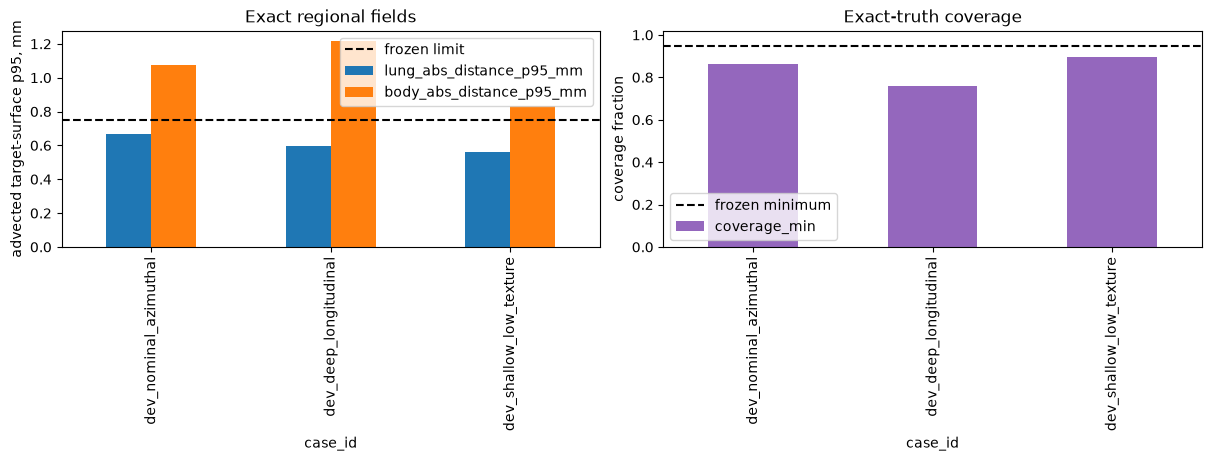

In [3]:
columns = [
    "case_id",
    "lung_abs_distance_p95_mm",
    "body_abs_distance_p95_mm",
    "abs_distance_p95_max_mm",
    "coverage_min",
    "gap_fraction",
    "collision_fraction",
    "truth_gate_pass",
    "gate_reasons",
]
display(summary[columns].set_index("case_id"))

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
distances = summary.set_index("case_id")[
    ["lung_abs_distance_p95_mm", "body_abs_distance_p95_mm"]
]
distances.plot.bar(ax=axes[0])
axes[0].axhline(
    float(summary["tolerance_mm"].iloc[0]),
    color="black",
    linestyle="--",
    label="frozen limit",
)
axes[0].set_ylabel("advected target-surface p95, mm")
axes[0].set_title("Exact regional fields")
axes[0].legend()

coverage = summary.set_index("case_id")["coverage_min"]
coverage.plot.bar(ax=axes[1], color="tab:purple")
axes[1].axhline(
    float(summary["required_coverage_min"].iloc[0]),
    color="black",
    linestyle="--",
    label="frozen minimum",
)
axes[1].set_ylim(0.0, 1.02)
axes[1].set_ylabel("coverage fraction")
axes[1].set_title("Exact-truth coverage")
axes[1].legend()
plt.show()

## Почему это не ошибка optimizer

Старый phantom создавал moving lung mask через inverse **lung field**, а body field связывал с lung только равенством normal component в окрестности fixed interface. J1.1 показал, что такое равенство не гарантирует совпадение конечных кривых поверхностей. Поэтому body truth систематически дальше от moving lung boundary, чем lung truth.

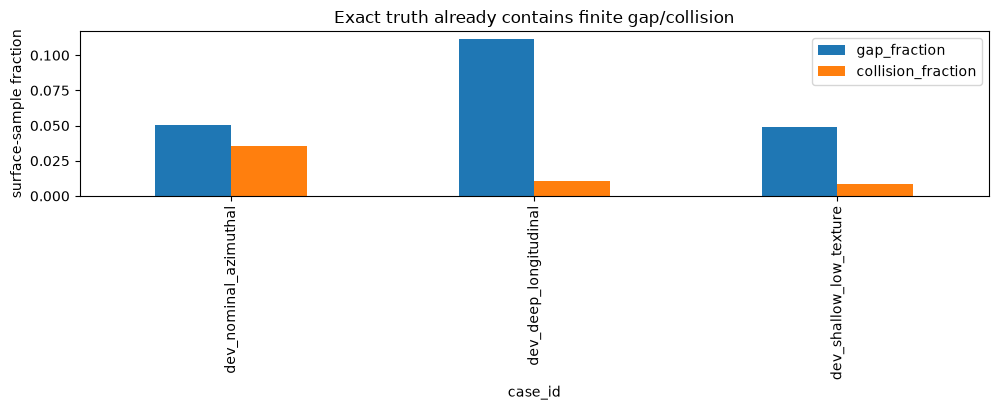

In [4]:
fractions = summary.set_index("case_id")[
    ["gap_fraction", "collision_fraction"]
]
axis = fractions.plot.bar(figsize=(10, 4.2))
axis.set_ylabel("surface-sample fraction")
axis.set_title("Exact truth already contains finite gap/collision")
axis.legend()
plt.tight_layout()
plt.show()

In [5]:
if manifest["all_truth_pass"] or bool(summary["truth_gate_pass"].any()):
    raise RuntimeError("Preflight verdict не соответствует frozen 0/3 result")
worst_p95 = float(summary["abs_distance_p95_max_mm"].max())
worst_coverage = float(summary["coverage_min"].min())
display(
    Markdown(
        "**J1.2 DEVELOPMENT BLOCKED: exact truth 0/3.** "
        f"Худший surface p95 = {worst_p95:.3f} мм, минимальный coverage = "
        f"{100 * worst_coverage:.1f}%. CUDA optimizer не запускался, challenge не "
        "загружался. Suite v1 нельзя чинить ослаблением thresholds: нужен новый "
        "generator, где lung/body transforms по построению отображают fixed interface "
        "в одну advected surface при разрешённом tangential slip. Только после exact "
        "truth PASS можно возобновить J1.2 search."
    )
)

**J1.2 DEVELOPMENT BLOCKED: exact truth 0/3.** Худший surface p95 = 1.217 мм, минимальный coverage = 75.8%. CUDA optimizer не запускался, challenge не загружался. Suite v1 нельзя чинить ослаблением thresholds: нужен новый generator, где lung/body transforms по построению отображают fixed interface в одну advected surface при разрешённом tangential slip. Только после exact truth PASS можно возобновить J1.2 search.